<a href="https://colab.research.google.com/github/JorgeMarquezPiedra/Afluencia-Cablebus-Trolebus-y-Tren-Ligero-Ciudad-de-Mexico-2022-a-2026-Python/blob/main/Afluencia_Transporte_Electricos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Leer datasets
cb = pd.read_csv('afluencia_desglosada_cb_01_2026.csv')
cb

,fecha,mes,anio,linea,tipo_pago,afluencia
0,2022-01-01,Enero,2022,Línea 1,Prepago,24975
1,2022-01-01,Enero,2022,Línea 1,Gratuidad,2175
2,2022-01-01,Enero,2022,Línea 2,Prepago,42050
3,2022-01-01,Enero,2022,Línea 2,Gratuidad,3920
4,2022-01-02,Enero,2022,Línea 1,Prepago,31814
...,...,...,...,...,...,...
6515,2026-01-29,Enero,2026,Linea 3,Gratuidad,2022
6516,2026-01-30,Enero,2026,Linea 3,Prepago,15905
6517,2026-01-30,Enero,2026,Linea 3,Gratuidad,1849
6518,2026-01-31,Enero,2026,Linea 3,Prepago,7879


In [ ]:
tb = pd.read_csv('afluencia_desglosada_trolebus_01_2026.csv')
tb

,fecha,mes,anio,linea,tipo_pago,afluencia
0,2022-01-01,Enero,2022,Línea 1,Boleto,16826
1,2022-01-01,Enero,2022,Línea 1,Prepago,5062
2,2022-01-01,Enero,2022,Línea 1,Gratuidad,9111
3,2022-01-01,Enero,2022,Línea 1 Nochebús,Boleto,131
4,2022-01-01,Enero,2022,Línea 1 Nochebús,Prepago,37
...,...,...,...,...,...,...
52624,2026-01-31,Enero,2026,Línea 12,Prepago,19586
52625,2026-01-31,Enero,2026,Línea 12,Gratuidad,5704
52626,2026-01-31,Enero,2026,Línea 13,Boleto,0
52627,2026-01-31,Enero,2026,Línea 13,Prepago,15342


In [ ]:
tl = pd.read_csv('afluencia_desglosada_tl_01_2026.csv')
tl

,fecha,mes,anio,tipo_pago,afluencia
0,2022-01-01,Enero,2022,Prepago,14251.00000
1,2022-01-01,Enero,2022,Gratuidad,1806.00000
2,2022-01-02,Enero,2022,Prepago,21875.00000
3,2022-01-02,Enero,2022,Gratuidad,2259.00000
4,2022-01-03,Enero,2022,Prepago,49290.00000
...,...,...,...,...,...
2979,2026-01-29,Enero,2026,Gratuidad,11461.53356
2980,2026-01-30,Enero,2026,Prepago,77066.00000
2981,2026-01-30,Enero,2026,Gratuidad,11604.27947
2982,2026-01-31,Enero,2026,Prepago,47682.00000


In [ ]:
# Información cb
cb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6520 entries, 0 to 6519
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   fecha      6520 non-null   object
 1   mes        6520 non-null   object
 2   anio       6520 non-null   int64 
 3   linea      6520 non-null   object
 4   tipo_pago  6520 non-null   object
 5   afluencia  6520 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 305.8+ KB


In [ ]:
# Información tb
tb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52629 entries, 0 to 52628
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   fecha      52629 non-null  object
 1   mes        52629 non-null  object
 2   anio       52629 non-null  int64 
 3   linea      52629 non-null  object
 4   tipo_pago  52629 non-null  object
 5   afluencia  52629 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 2.4+ MB


In [ ]:
# Información tl
tl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2984 entries, 0 to 2983
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      2984 non-null   object 
 1   mes        2984 non-null   object 
 2   anio       2984 non-null   int64  
 3   tipo_pago  2984 non-null   object 
 4   afluencia  2984 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 116.7+ KB


In [ ]:
# Pasat fechas de cb, tb y tl a formato datetime
cb['fecha'] = pd.to_datetime(cb['fecha'])
tb['fecha'] = pd.to_datetime(tb['fecha'])
tl['fecha'] = pd.to_datetime(tl['fecha'])

In [ ]:
# Pasar afluencia a int64 en tb
tl['afluencia'] = tl['afluencia'].astype('int64')
tl

,fecha,mes,anio,tipo_pago,afluencia
0,2022-01-01,Enero,2022,Prepago,14251
1,2022-01-01,Enero,2022,Gratuidad,1806
2,2022-01-02,Enero,2022,Prepago,21875
3,2022-01-02,Enero,2022,Gratuidad,2259
4,2022-01-03,Enero,2022,Prepago,49290
...,...,...,...,...,...
2979,2026-01-29,Enero,2026,Gratuidad,11461
2980,2026-01-30,Enero,2026,Prepago,77066
2981,2026-01-30,Enero,2026,Gratuidad,11604
2982,2026-01-31,Enero,2026,Prepago,47682


In [ ]:
# Revisar valores únicos de linea en dataframe cb
cb['linea'].unique()

array(['Línea 1', 'Línea 2', 'Linea 1', 'Linea 2', 'Linea 3'],
      dtype=object)

In [ ]:
# Homogenizar valores de linea
cb['linea'] = cb['linea'].str.replace('Linea', 'Línea', regex = False)

cb['linea'].unique()

array(['Línea 1', 'Línea 2', 'Línea 3'], dtype=object)

In [ ]:
# Revisar valores únicos de linea en dataframe tl
tb['linea'].unique()

array(['Línea 1', 'Línea 1 Nochebús', 'Línea 2', 'Línea 3', 'Línea 4',
       'Línea 5', 'Línea 6', 'Línea 7', 'Línea 8', 'Línea 9',
       'Línea 10 (Trolebús elevado)', 'Línea 10', 'linea_ 1',
       'linea_ 1_nochebus', 'linea_ 2', 'linea_ 3', 'linea_ 4',
       'linea_ 5', 'linea_ 6', 'linea_ 7', 'linea_ 8', 'linea_ 9',
       'linea_ 10', 'Línea 12', 'Línea 11', 'Línea 13'], dtype=object)

In [ ]:
# Homogenizar valores de linea
tb['linea'] = tb['linea'].str.replace('Linea', 'Línea', regex = False)
tb['linea'] = tb['linea'].str.replace('linea_', 'Línea', regex = False)
tb['linea'] = tb['linea'].str.replace('linea', 'Línea', regex = False)
tb['linea'] = tb['linea'].str.replace('Línea 1_nochebus', 'Línea 1 Nochebús', regex = False)
tb['linea'] = tb['linea'].str.replace('Línea 1 Nochebús', 'Línea 1 (Nochebús)', regex = False)
tb['linea'] = tb['linea'].str.replace('Línea 10 (Trolebús elevado)', 'Línea 10 (Trolebús Elevado)', regex = False)

tb['linea'].unique()

array(['Línea 1', 'Línea 1 (Nochebús)', 'Línea 2', 'Línea 3', 'Línea 4',
       'Línea 5', 'Línea 6', 'Línea 7', 'Línea 8', 'Línea 9',
       'Línea 10 (Trolebús Elevado)', 'Línea 10', 'Línea 12', 'Línea 11',
       'Línea 13'], dtype=object)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

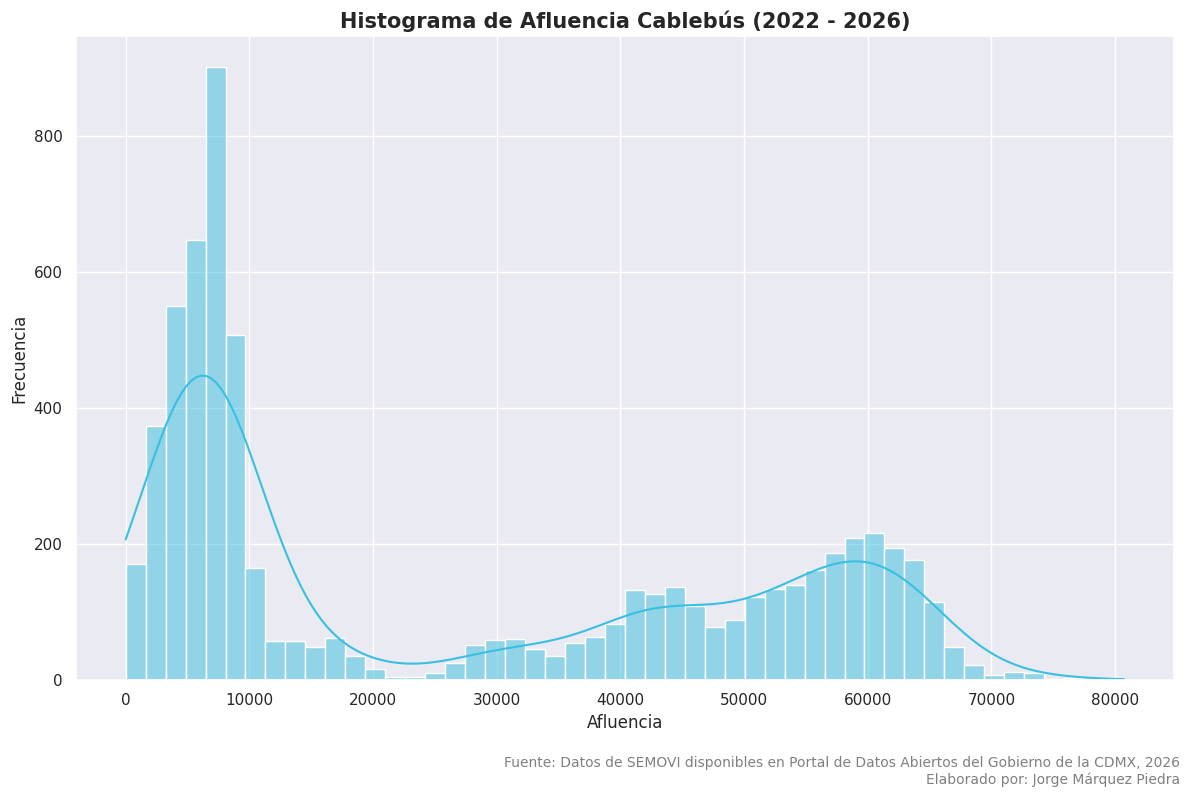

In [ ]:
# Histograma de afluencia
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.histplot(data = cb, x = 'afluencia', bins = 50, color = '#39c0e0', kde = True)
plt.title('Histograma de Afluencia Cablebús (2022 - 2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Afluencia')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('cablebus_histograma_afluencia.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

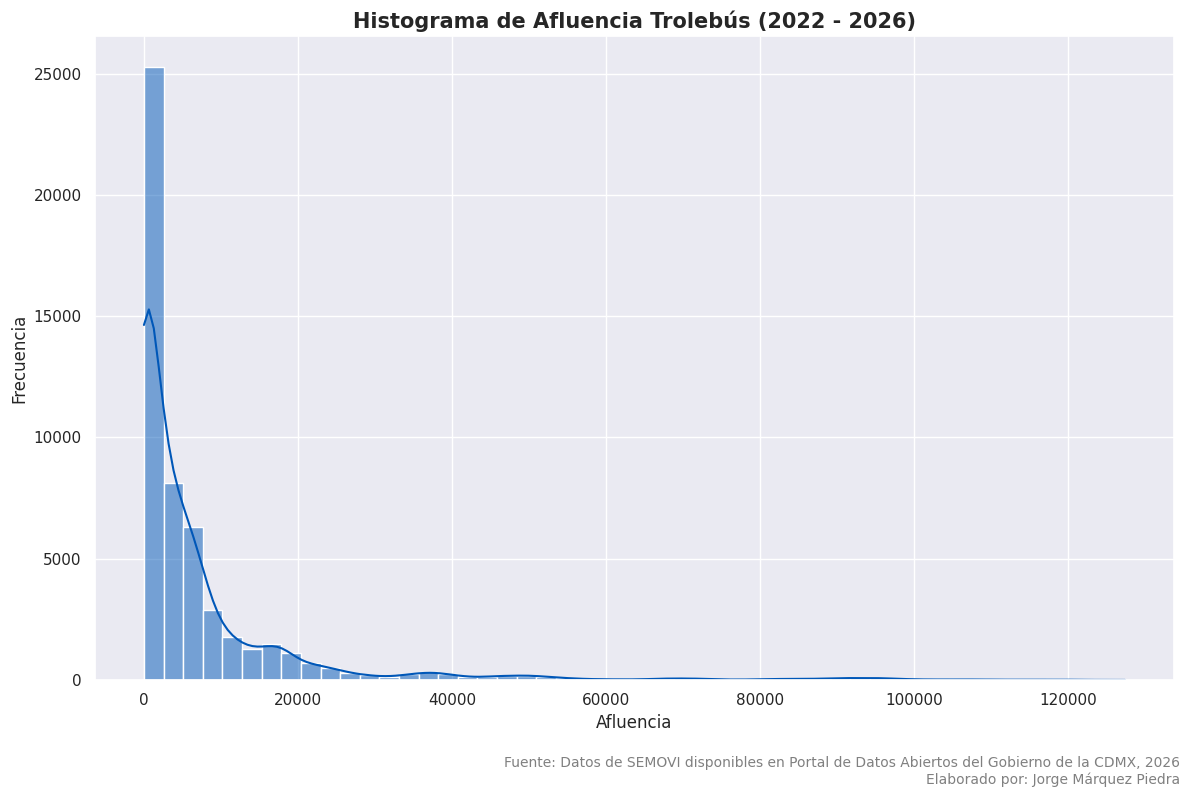

In [ ]:
# Histograma de afluencia
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.histplot(data = tb, x = 'afluencia', bins = 50, color = '#0057b8', kde = True)
plt.title('Histograma de Afluencia Trolebús (2022 - 2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Afluencia')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('trolebus_histograma_afluencia.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

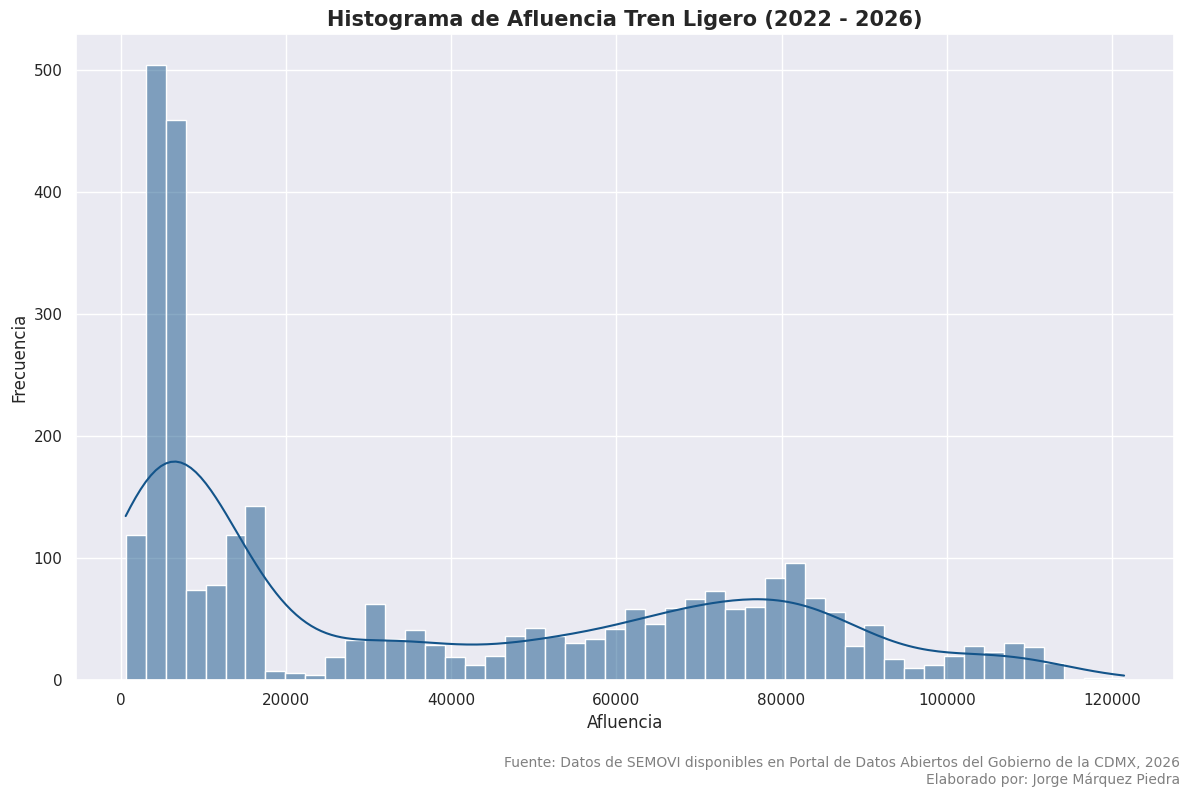

In [ ]:
# Histograma de afluencia
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.histplot(data = tl, x = 'afluencia', bins = 50, color = '#13548a', kde = True)
plt.title('Histograma de Afluencia Tren Ligero (2022 - 2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Afluencia')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('trenl_histograma_afluencia.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

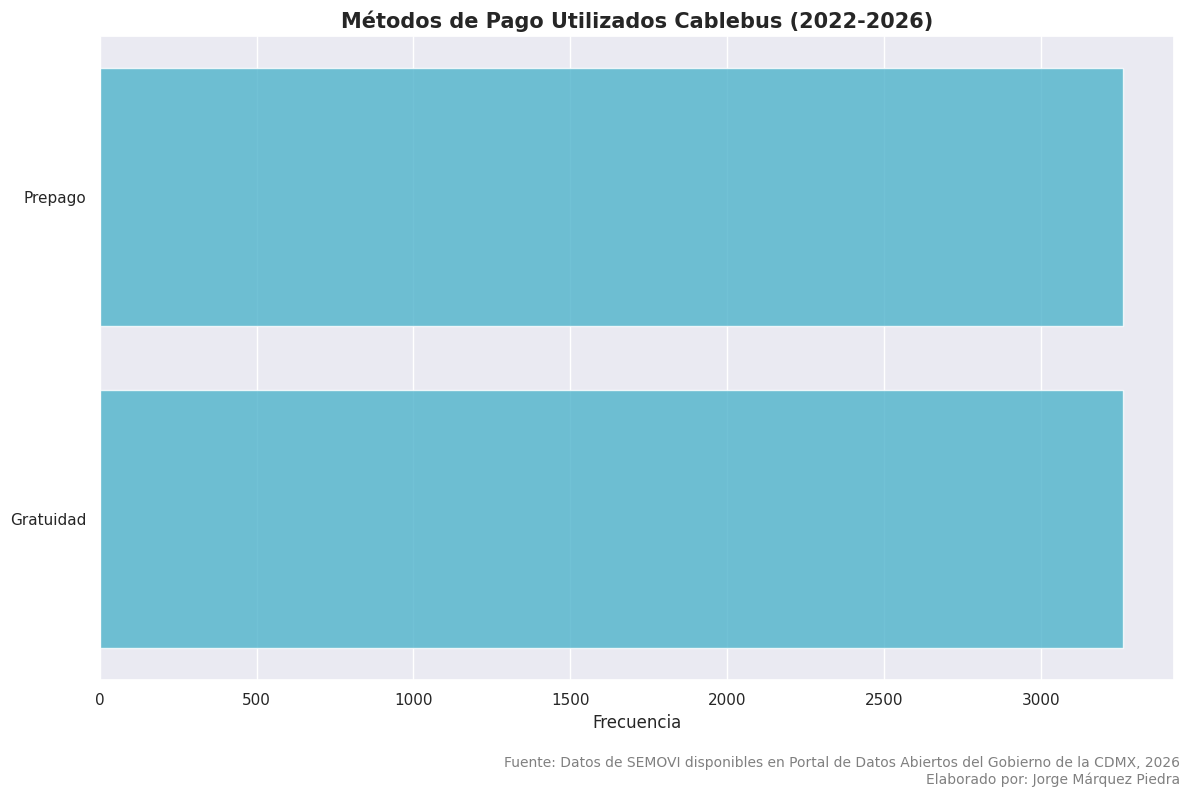

In [ ]:
# Countplot tipo de pago
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.countplot(data = cb, y = 'tipo_pago', color = '#39c0e0', alpha = 0.8, order = cb['tipo_pago'].value_counts().index)
plt.title('Métodos de Pago Utilizados Cablebus (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Frecuencia')
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('cablebus_countplot_pago.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

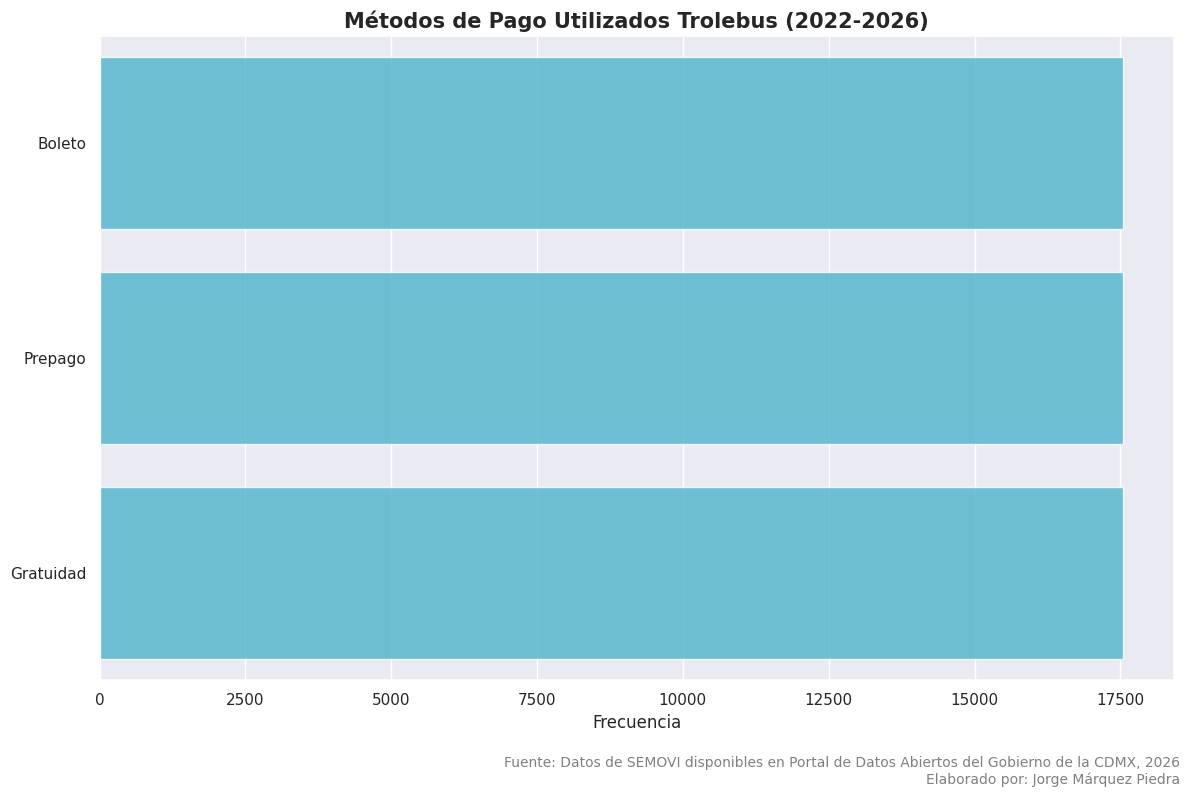

In [ ]:
# Countplot tipo de pago
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.countplot(data = tb, y = 'tipo_pago', color = '#39c0e0', alpha = 0.8, order = tb['tipo_pago'].value_counts().index)
plt.title('Métodos de Pago Utilizados Trolebus (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Frecuencia')
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('trolebus_countplot_pago.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

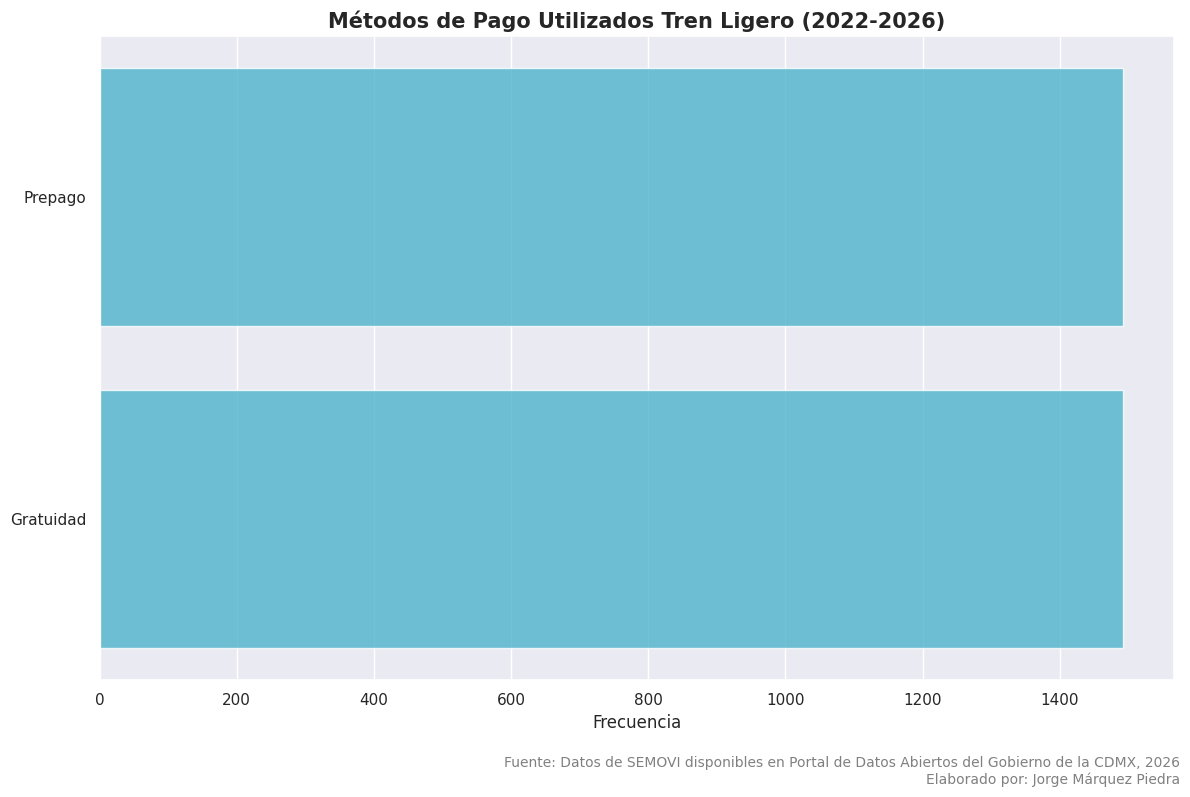

In [ ]:
# Countplot tipo de pago
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.countplot(data = tl, y = 'tipo_pago', color = '#39c0e0', alpha = 0.8, order = tl['tipo_pago'].value_counts().index)
plt.title('Métodos de Pago Utilizados Tren Ligero (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Frecuencia')
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('trenl_countplot_pago.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

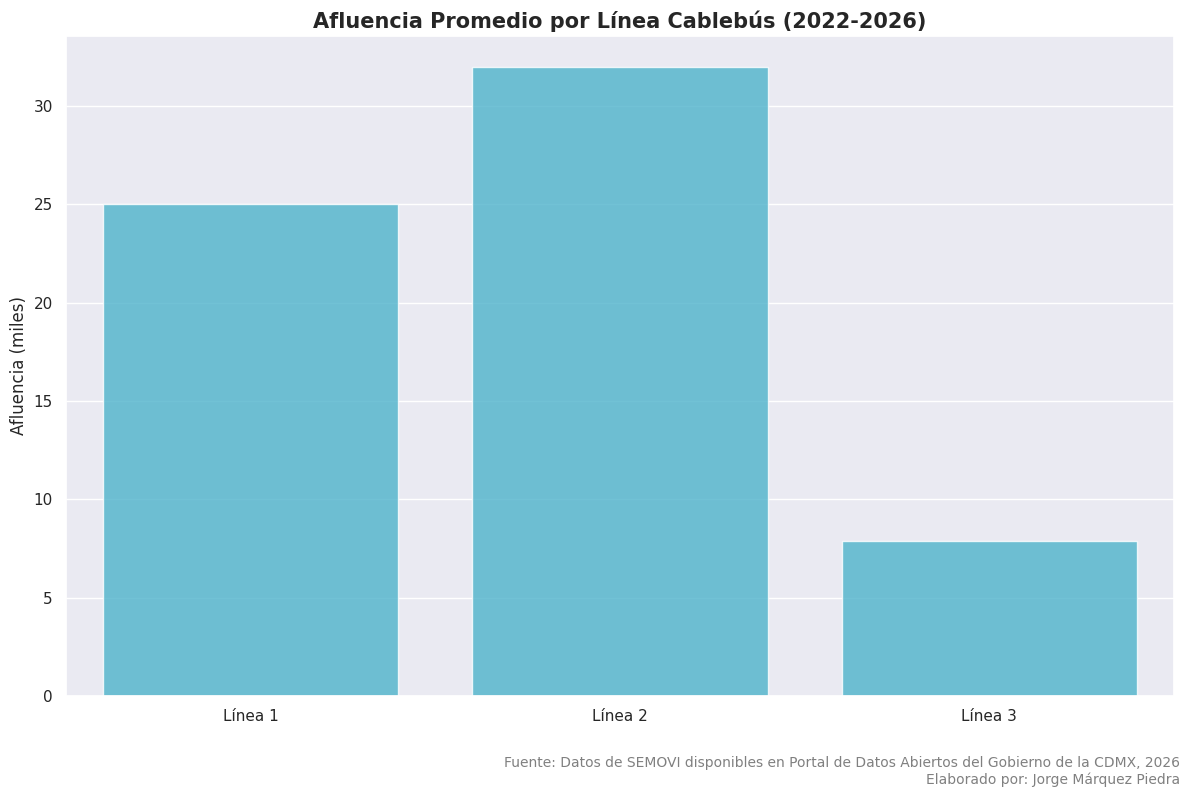

In [ ]:
# Afluencia promedio por línea
cb['afluencia_miles'] = cb['afluencia'] / 1_000

plt.figure(figsize=(12, 8))
sns.set_theme()
sns.barplot(data = cb, x = 'linea', y = 'afluencia_miles', estimator = 'mean', color = '#39c0e0', alpha = 0.8, errorbar = None)
plt.title('Afluencia Promedio por Línea Cablebús (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (miles)')
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('cablebus_afluencia_promedio_linea.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

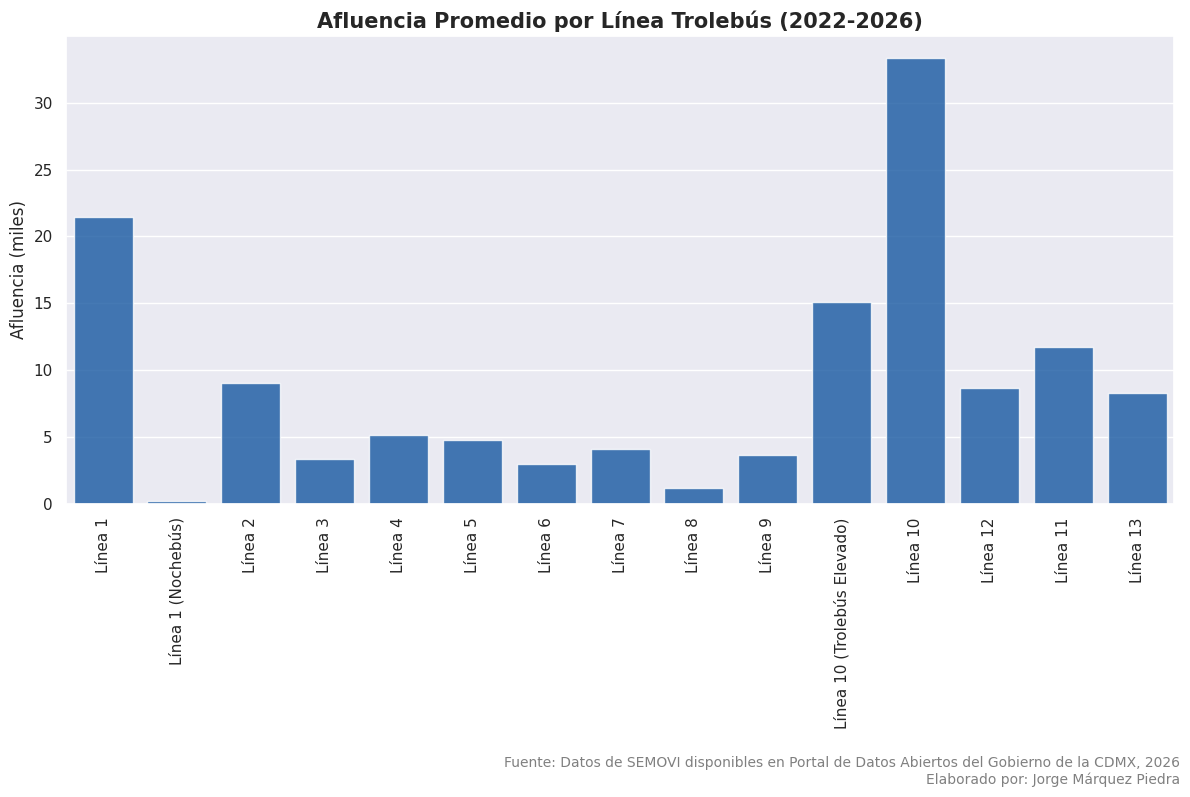

In [ ]:
# Afluencia promedio por línea
tb['afluencia_miles'] = tb['afluencia'] / 1_000

plt.figure(figsize=(12, 8))
sns.set_theme()
sns.barplot(data = tb, x = 'linea', y = 'afluencia_miles', estimator = 'mean', color = '#0057b8', alpha = 0.8, errorbar = None)
plt.title('Afluencia Promedio por Línea Trolebús (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (miles)')
plt.xticks(rotation = 90)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.36)
plt.savefig('trolebus_afluencia_promedio_linea.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

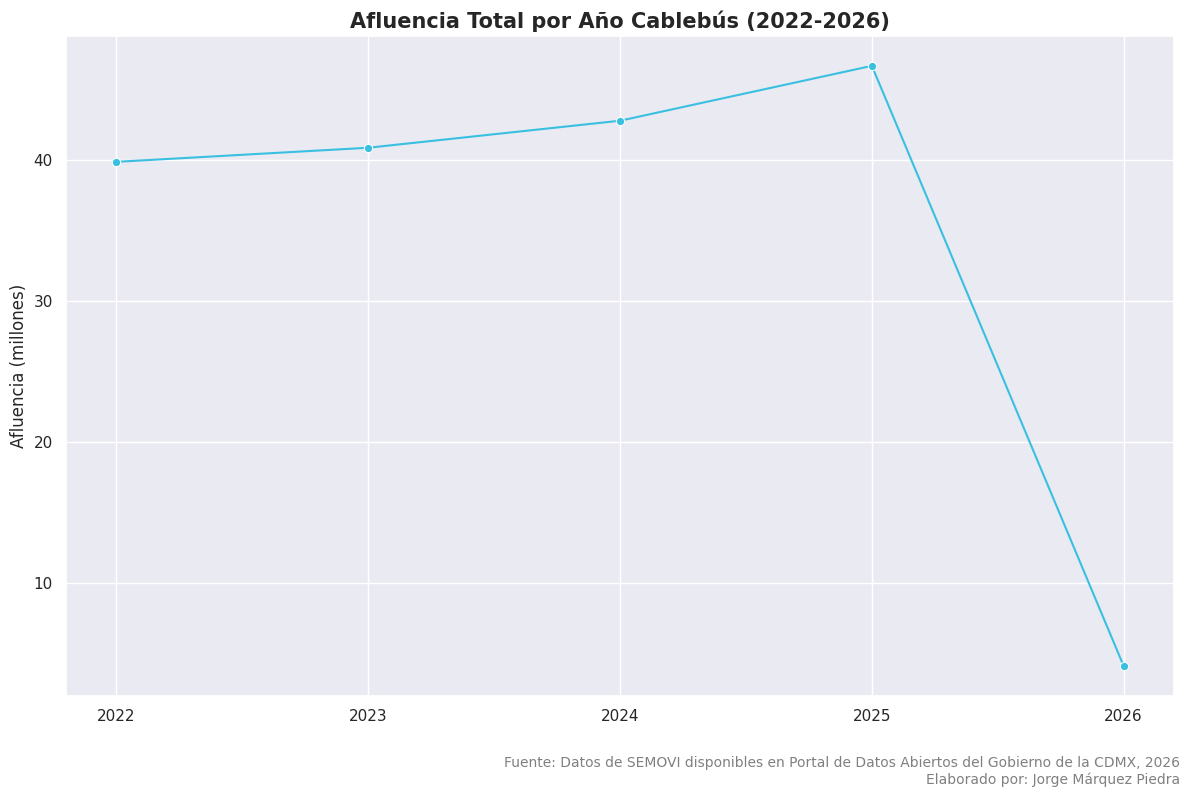

In [ ]:
# Afluencia por año Cablebús
cb_por_anio = cb.groupby('anio')['afluencia'].sum().reset_index()

# Convertir a millones
cb_por_anio['afluencia_millones'] = cb_por_anio['afluencia'] / 1_000_000

# Gráfico de línea de afluencia por año
plt.figure(figsize=(12, 8))
sns.lineplot(data = cb_por_anio, x = 'anio', y = 'afluencia_millones', marker = 'o', color = '#39c0e0')
plt.title('Afluencia Total por Año Cablebús (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (millones)')
plt.xticks(cb_por_anio['anio'].unique())
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('cablebus_total_por_año.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

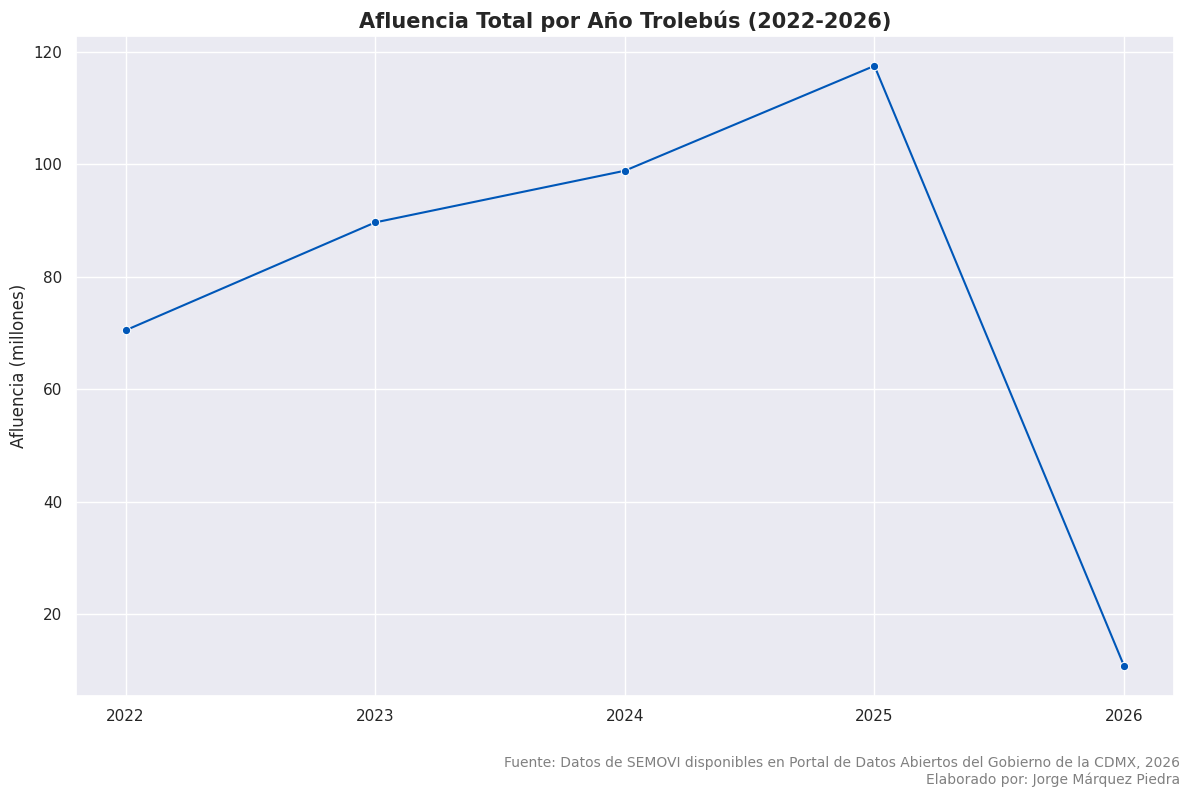

In [ ]:
# Afluencia por año Cablebús
tb_por_anio = tb.groupby('anio')['afluencia'].sum().reset_index()

# Convertir a millones
tb_por_anio['afluencia_millones'] = tb_por_anio['afluencia'] / 1_000_000

# Gráfico de línea de afluencia por año
plt.figure(figsize=(12, 8))
sns.lineplot(data = tb_por_anio, x = 'anio', y = 'afluencia_millones', marker = 'o', color = '#0057b8')
plt.title('Afluencia Total por Año Trolebús (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (millones)')
plt.xticks(cb_por_anio['anio'].unique())
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('trolebus_total_por_año.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

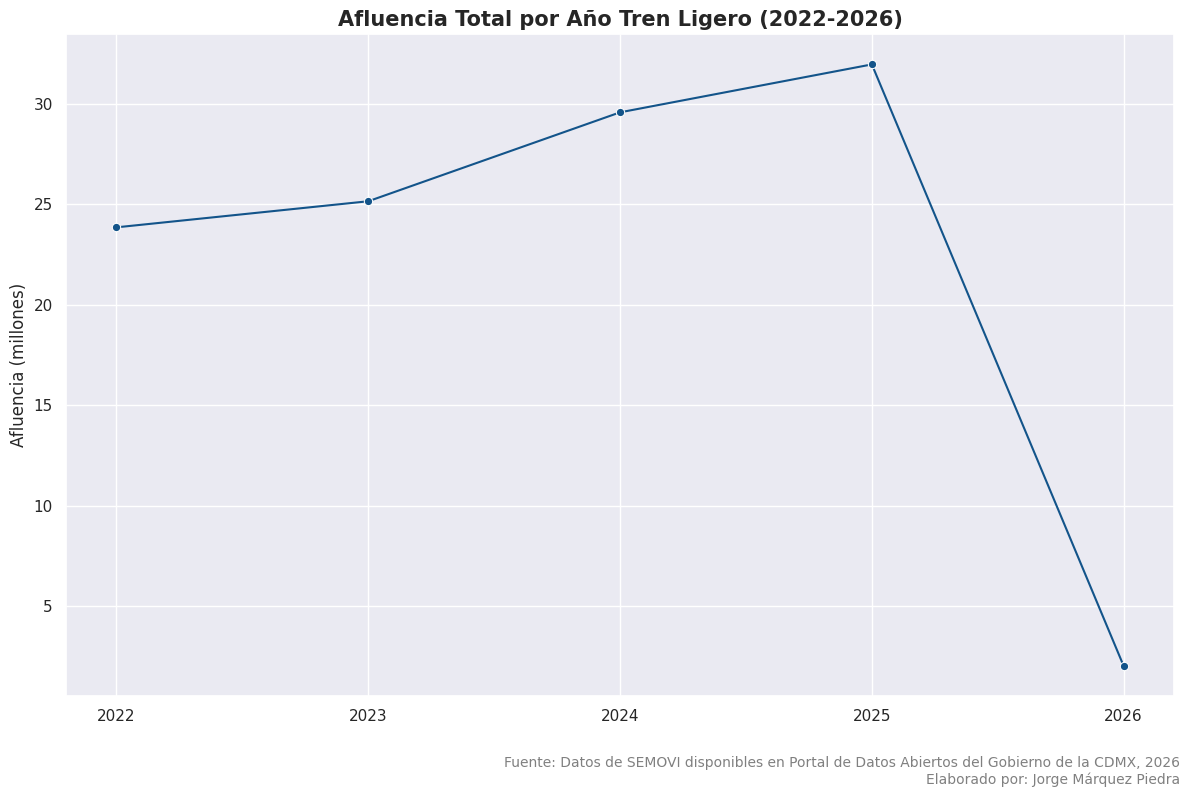

In [ ]:
# Afluencia por año Cablebús
tl_por_anio = tl.groupby('anio')['afluencia'].sum().reset_index()

# Convertir a millones
tl_por_anio['afluencia_millones'] = tl_por_anio['afluencia'] / 1_000_000

# Gráfico de línea de afluencia por año
plt.figure(figsize=(12, 8))
sns.lineplot(data = tl_por_anio, x = 'anio', y = 'afluencia_millones', marker = 'o', color = '#13548a')
plt.title('Afluencia Total por Año Tren Ligero (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (millones)')
plt.xticks(cb_por_anio['anio'].unique())
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('trenl_total_por_año.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

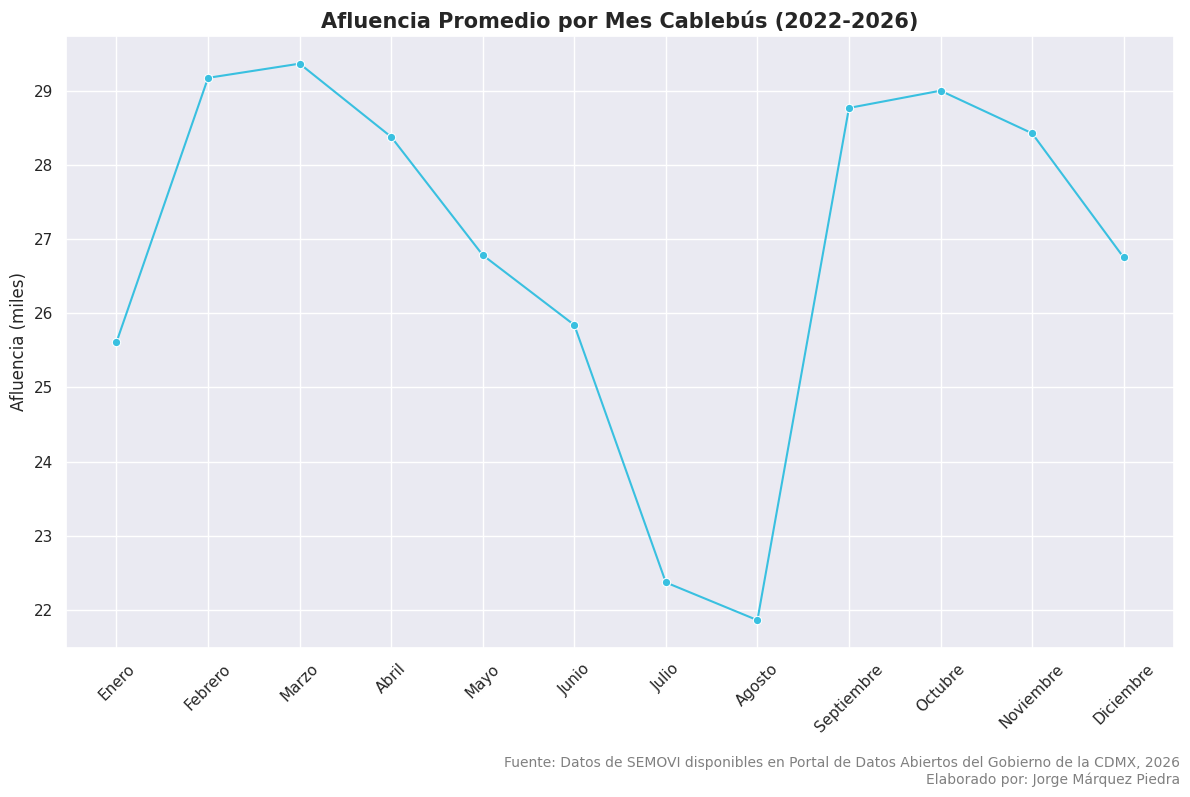

In [ ]:
# Afluencia por mes Cablebus
cb_por_mes = cb.groupby('mes')['afluencia'].mean().reset_index()

# Definir el orden correcto de meses
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Ordenar el dataframe usando el orden de meses
cb_por_mes['mes'] = pd.Categorical(cb_por_mes['mes'], categories = orden_meses, ordered = True)
cb_por_mes = cb_por_mes.sort_values('mes')

# Convertir a miles
cb_por_mes['afluencia_miles'] = cb_por_mes['afluencia'] / 1_000

# Gráfico de línea de afluencia por año
plt.figure(figsize=(12, 8))
sns.lineplot(data = cb_por_mes, x = 'mes', y = 'afluencia_miles', marker = 'o', color = '#39c0e0')
plt.title('Afluencia Promedio por Mes Cablebús (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (miles)')
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('cablebus_promedio_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

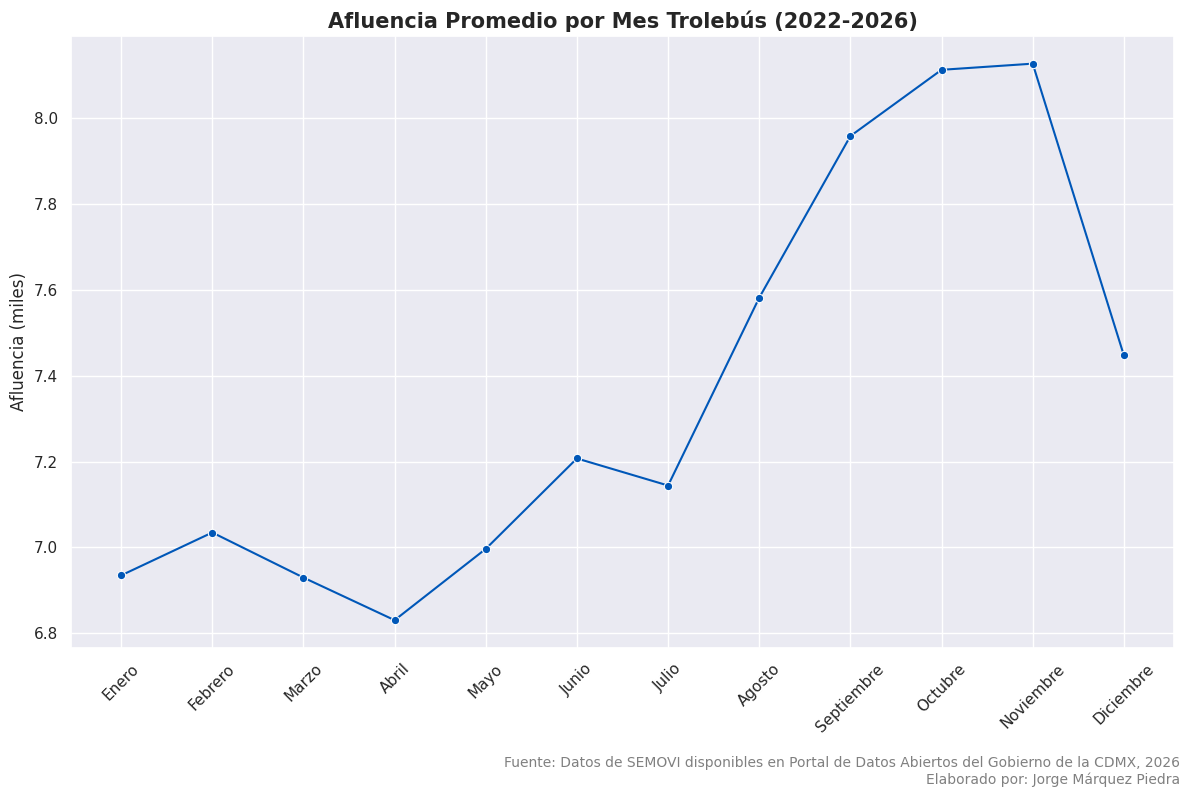

In [ ]:
# Afluencia por mes Trolebus
tb_por_mes = tb.groupby('mes')['afluencia'].mean().reset_index()

# Ordenar el dataframe usando el orden de meses
tb_por_mes['mes'] = pd.Categorical(tb_por_mes['mes'], categories = orden_meses, ordered = True)
tb_por_mes = tb_por_mes.sort_values('mes')

# Convertir a miles
tb_por_mes['afluencia_miles'] = tb_por_mes['afluencia'] / 1_000

# Gráfico de línea de afluencia por año
plt.figure(figsize=(12, 8))
sns.lineplot(data = tb_por_mes, x = 'mes', y = 'afluencia_miles', marker = 'o', color = '#0057b8')
plt.title('Afluencia Promedio por Mes Trolebús (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (miles)')
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('trolebus_promedio_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

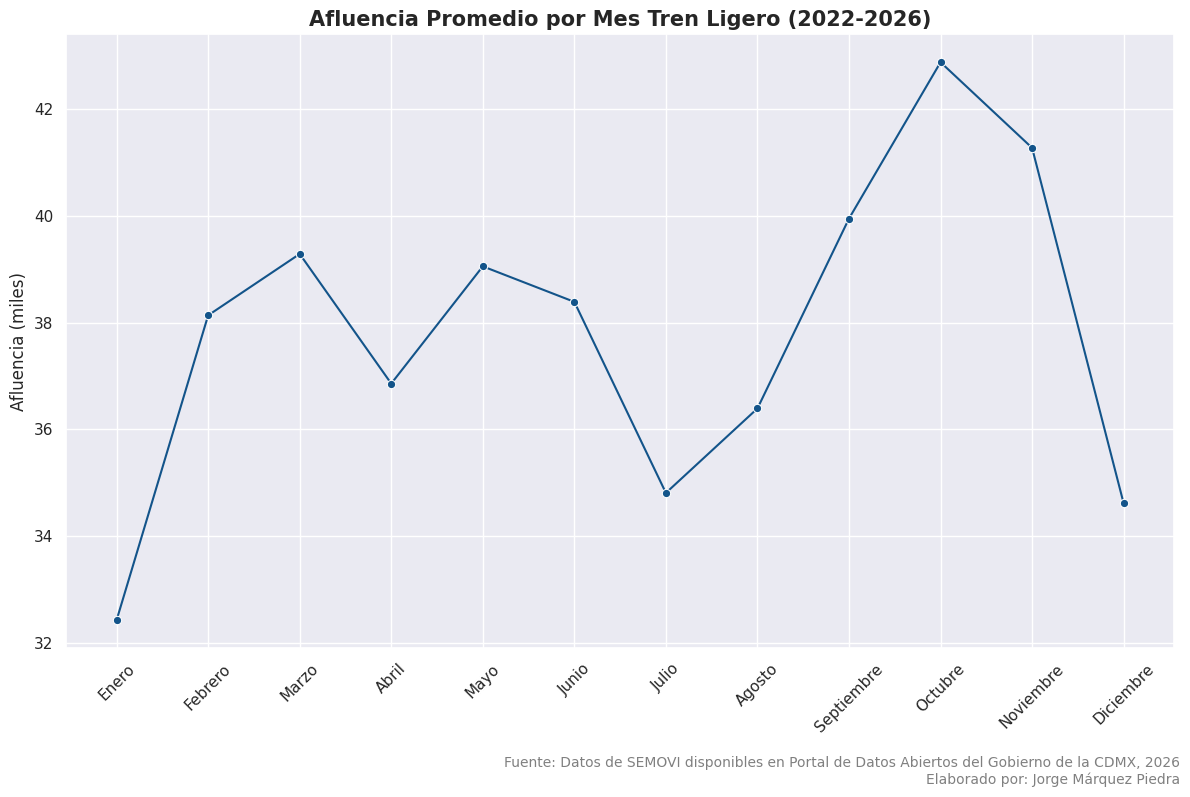

In [ ]:
# Afluencia por mes Trolebus
tl_por_mes = tl.groupby('mes')['afluencia'].mean().reset_index()

# Ordenar el dataframe usando el orden de meses
tl_por_mes['mes'] = pd.Categorical(tl_por_mes['mes'], categories = orden_meses, ordered = True)
tl_por_mes = tl_por_mes.sort_values('mes')

# Convertir a miles
tl_por_mes['afluencia_miles'] = tl_por_mes['afluencia'] / 1_000

# Gráfico de línea de afluencia por año
plt.figure(figsize=(12, 8))
sns.lineplot(data = tl_por_mes, x = 'mes', y = 'afluencia_miles', marker = 'o', color = '#13548a')
plt.title('Afluencia Promedio por Mes Tren Ligero (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (miles)')
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('trenl_promedio_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

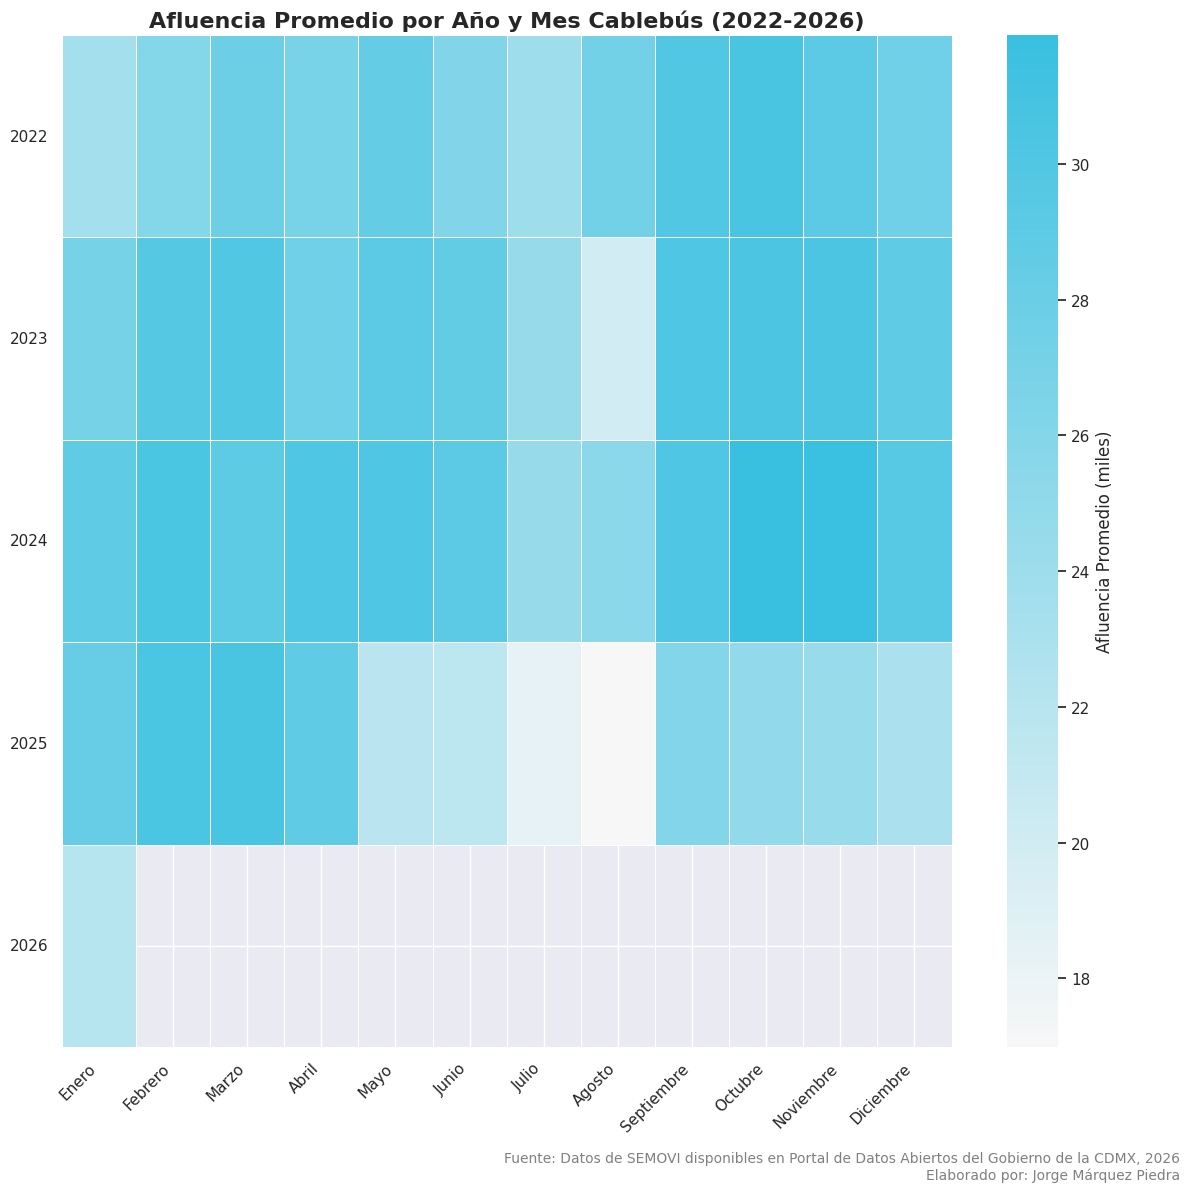

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# Crear pivot
pivot_cb = cb.pivot_table(values = 'afluencia', index = 'anio', columns = 'mes', aggfunc = 'mean')

# Convertir a miles
pivot_cb = pivot_cb / 1_000

# Ordenar los meses para el mapa
pivot_cb = pivot_cb[orden_meses]

# Crear paleta personalizada para Cablebús
custom_cb = LinearSegmentedColormap.from_list("cb_palette", ["#f7f7f7", "#39c0e0"])

# Heatmap
plt.figure(figsize = (12, 12))
sns.set_theme()
sns.heatmap(pivot_cb, cmap = custom_cb, fmt = ".0f", linewidths = .5, linecolor = "#ffffff",
            cbar_kws = {'label': 'Afluencia Promedio (miles)'}, annot = False)
plt.title('Afluencia Promedio por Año y Mes Cablebús (2022-2026)', fontsize = 16, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('heatmap_cablebus_2026.png', dpi = 300, bbox_inches = 'tight')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

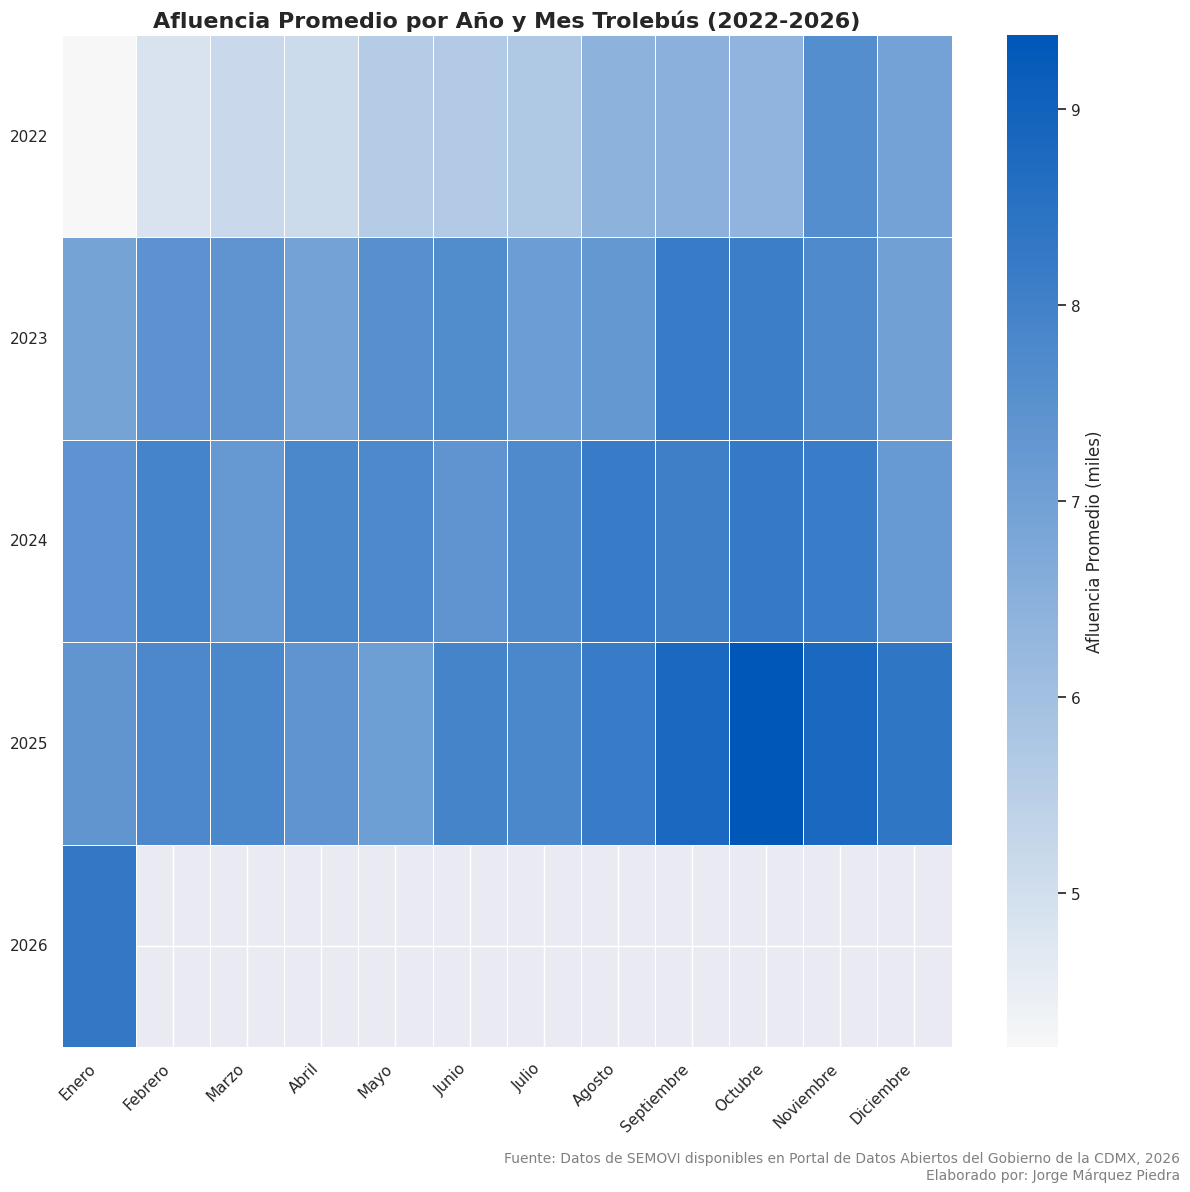

In [ ]:
# Crear pivot
pivot_tb = tb.pivot_table(values = 'afluencia', index = 'anio', columns = 'mes', aggfunc = 'mean')

# Convertir a miles
pivot_tb = pivot_tb / 1_000

# Ordenar los meses para el mapa
pivot_tb = pivot_tb[orden_meses]

# Crear paleta personalizada para Trolebús
custom_tb = LinearSegmentedColormap.from_list("tb_palette", ["#f7f7f7", "#0057b8"])

# Heatmap
plt.figure(figsize = (12, 12))
sns.set_theme()
sns.heatmap(pivot_tb, cmap = custom_tb, fmt = ".0f", linewidths = .5, linecolor = "#ffffff",
            cbar_kws = {'label': 'Afluencia Promedio (miles)'}, annot = False)
plt.title('Afluencia Promedio por Año y Mes Trolebús (2022-2026)', fontsize = 16, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('heatmap_trolebus_2026.png', dpi = 300, bbox_inches = 'tight')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

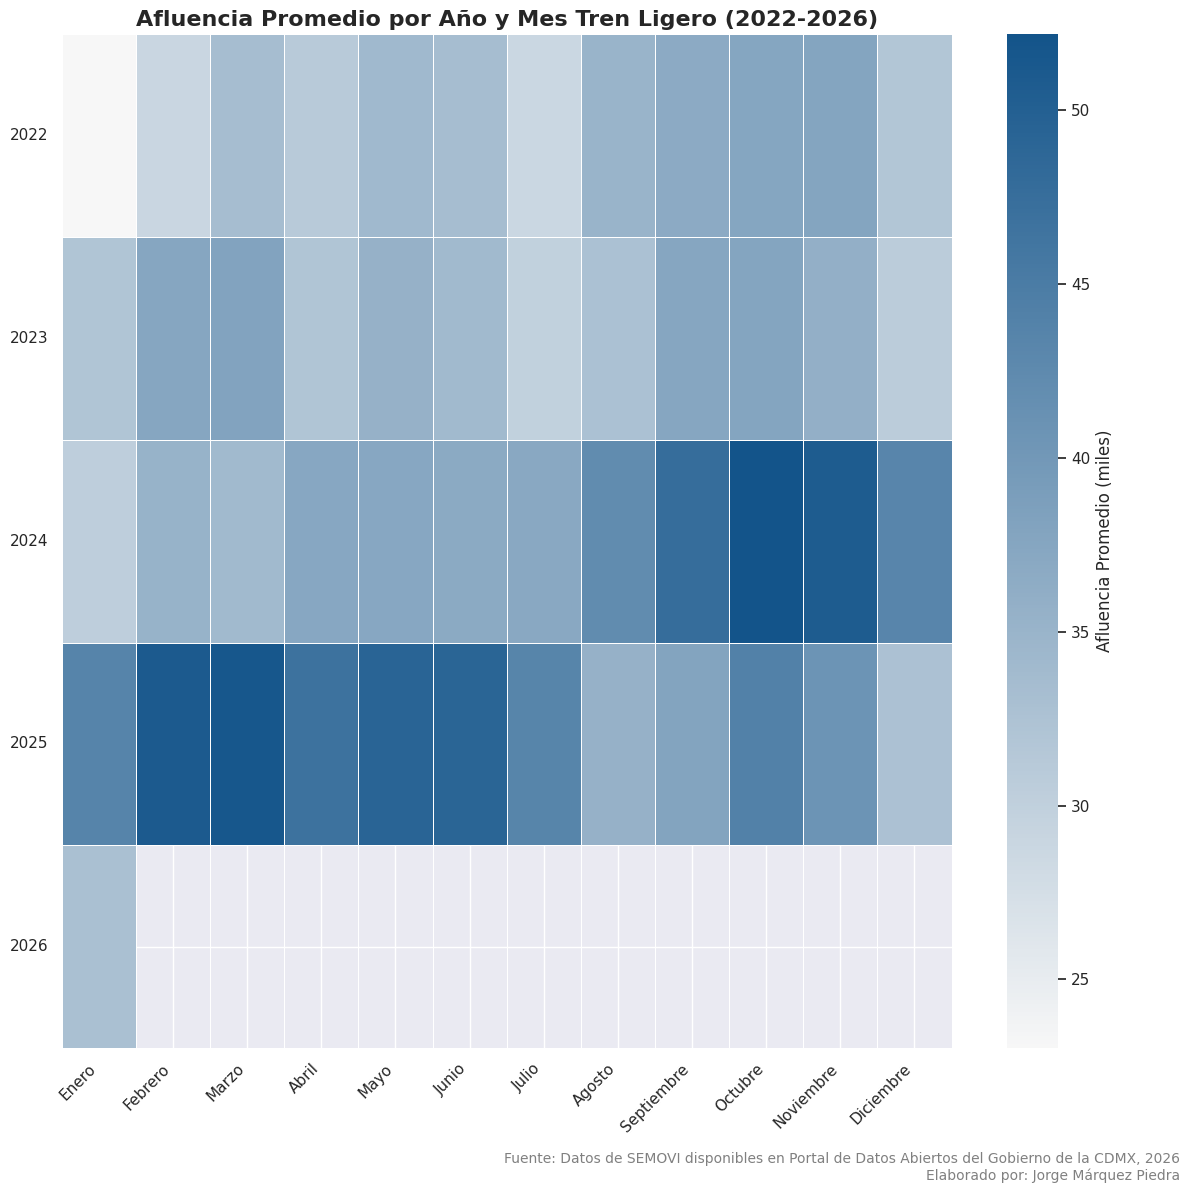

In [ ]:
# Crear pivot
pivot_tl = tl.pivot_table(values = 'afluencia', index = 'anio', columns = 'mes', aggfunc = 'mean')

# Convertir a miles
pivot_tl = pivot_tl / 1_000

# Ordenar los meses para el mapa
pivot_tl = pivot_tl[orden_meses]

# Crear paleta personalizada para Tren Ligero
custom_tl = LinearSegmentedColormap.from_list("tl_palette", ["#f7f7f7", "#13548a"])

# Heatmap
plt.figure(figsize = (12, 12))
sns.set_theme()
sns.heatmap(pivot_tl, cmap = custom_tl, fmt = ".0f", linewidths = .5, linecolor = "#ffffff",
            cbar_kws = {'label': 'Afluencia Promedio (miles)'}, annot = False)
plt.title('Afluencia Promedio por Año y Mes Tren Ligero (2022-2026)', fontsize = 16, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('heatmap_trenl_2026.png', dpi = 300, bbox_inches = 'tight')
plt